# Week 2: Text Preprocessing and Baseline Model

## Project: Sentiment Classification of Tweets Using Deep Learning

In this notebook, I continue the project by preparing the tweet text for machine learning and training the first baseline model.

The main goals of Week 2 are:

- load the Sentiment140 dataset;
- clean tweet text;
- convert labels into binary format;
- split data into train, validation, and test sets;
- convert text into TF-IDF features;
- train a Logistic Regression baseline model;
- evaluate the model using accuracy, precision, recall, F1-score, and confusion matrix.

The baseline model is important because it gives a simple result for comparison with the deep learning model in Week 3.

In [40]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import html
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Balanced Sample for Faster Training

The full Sentiment140 dataset contains 1.6 million tweets.  
Training on the full dataset can take a lot of time and memory.

For Week 2 baseline training, I use a balanced sample from both classes.  
This makes the experiment faster and keeps the number of negative and positive examples equal.

In [43]:
# Use balanced sample for faster baseline training

USE_SAMPLE = True
SAMPLE_PER_CLASS = 100000

if USE_SAMPLE:
    negative_sample = df[df["label"] == 0].sample(
        n=min(SAMPLE_PER_CLASS, len(df[df["label"] == 0])),
        random_state=42
    )
    
    positive_sample = df[df["label"] == 1].sample(
        n=min(SAMPLE_PER_CLASS, len(df[df["label"] == 1])),
        random_state=42
    )
    
    df_model = pd.concat([negative_sample, positive_sample], axis=0)
    df_model = df_model.sample(frac=1, random_state=42).reset_index(drop=True)
    
else:
    df_model = df.copy()

print("Dataset used for Week 2 baseline:")
print(df_model["sentiment"].value_counts())
print("\nShape:", df_model.shape)

Dataset used for Week 2 baseline:
sentiment
positive    100000
negative    100000
Name: count, dtype: int64

Shape: (200000, 8)


## 2. Text Cleaning

Tweets often contain noisy elements such as:

- links;
- usernames;
- hashtags;
- extra spaces;
- special symbols;
- HTML entities.

The cleaning function prepares tweet text for the baseline model.

In [44]:
# Text cleaning function

def clean_tweet(text):
    text = str(text)
    
    # Convert HTML entities, for example &amp; -> &
    text = html.unescape(text)
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Replace usernames with token
    text = re.sub(r"@\w+", " user ", text)
    
    # Remove hashtag symbol but keep hashtag word
    text = re.sub(r"#", "", text)
    
    # Remove non-letter symbols except spaces and apostrophes
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [45]:
# Apply cleaning function

df_model["clean_text"] = df_model["text"].apply(clean_tweet)

# Show original and cleaned examples
df_model[["text", "clean_text", "sentiment"]].head(10)

,text,clean_text,sentiment
0,Looks like the sun finally located Trondheim ;...,looks like the sun finally located trondheim h...,positive
1,A long weekend begins. The sun is shining and ...,a long weekend begins the sun is shining and i...,negative
2,to the beach we go! hope it stays nice...,to the beach we go hope it stays nice,positive
3,@JBFutureboy I missed it busted need to do a ...,user i missed it busted need to do a reunion t...,negative
4,Why I can't change my background image??,why i can't change my background image,negative
5,my gap year is going so quick,my gap year is going so quick,negative
6,@shemightbedead did u like it? i did! i liked...,user did u like it i did i liked the song and ...,positive
7,@yoitsadrian churchs. your answer. my demise.,user churchs your answer my demise,positive
8,@michaelsainz You HAVE to Air Guitar that you ...,user you have to air guitar that you know it's...,positive
9,"oh, where's my iPhone? I can't find it anywher...",oh where's my iphone i can't find it anywhere ...,negative


In [46]:
# Check empty texts after cleaning

empty_texts = (df_model["clean_text"].str.len() == 0).sum()

print("Number of empty texts after cleaning:", empty_texts)

# Remove empty texts
df_model = df_model[df_model["clean_text"].str.len() > 0].copy()

print("Shape after removing empty texts:", df_model.shape)

Number of empty texts after cleaning: 2
Shape after removing empty texts: (199998, 9)


## 3. Train / Validation / Test Split

The data is divided into three parts:

- training set: used to train the model;
- validation set: used to check model performance during development;
- test set: used for final evaluation.

I use stratified splitting to keep the class balance in all parts.

In [47]:
# Define input and target

X = df_model["clean_text"]
y = df_model["label"]

# First split: 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split: 10% validation, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nValidation label distribution:")
print(y_val.value_counts(normalize=True).round(3))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train size: 159998
Validation size: 20000
Test size: 20000

Train label distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Validation label distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64

Test label distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


## 4. TF-IDF Vectorization

Machine learning models cannot work directly with raw text.  
Therefore, I convert the cleaned tweet text into numerical features using TF-IDF.

TF-IDF gives higher importance to words that are useful for distinguishing documents.

In [48]:
# Create TF-IDF vectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

# Fit only on training data
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform validation and test data
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF feature matrix shapes:")
print("Train:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Test:", X_test_tfidf.shape)

TF-IDF feature matrix shapes:
Train: (159998, 50000)
Validation: (20000, 50000)
Test: (20000, 50000)


## 5. Baseline Model: Logistic Regression

The baseline model is Logistic Regression with TF-IDF features.

This model is simple, fast, and commonly used for text classification.  
It will be compared with the deep learning model in the next week.

In [49]:
# Train Logistic Regression baseline model

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(X_train_tfidf, y_train)

print("Baseline Logistic Regression model trained successfully.")

Baseline Logistic Regression model trained successfully.


## 6. Validation Evaluation

First, I evaluate the baseline model on the validation set.  
This helps to check the model performance before final testing.

In [50]:
# Predict on validation set

y_val_pred = baseline_model.predict(X_val_tfidf)

# Calculate validation metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print("Validation Results")
print("------------------")
print("Accuracy:", round(val_accuracy, 4))
print("Precision:", round(val_precision, 4))
print("Recall:", round(val_recall, 4))
print("F1-score:", round(val_f1, 4))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=["negative", "positive"]))

Validation Results
------------------
Accuracy: 0.7988
Precision: 0.7943
Recall: 0.8065
F1-score: 0.8004

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.79      0.80     10000
    positive       0.79      0.81      0.80     10000

    accuracy                           0.80     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.80      0.80      0.80     20000



## 7. Test Evaluation

The test set is used for final baseline evaluation.  
The model has not seen these examples during training.

In [51]:
# Predict on test set

y_test_pred = baseline_model.predict(X_test_tfidf)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Test Results")
print("------------")
print("Accuracy:", round(test_accuracy, 4))
print("Precision:", round(test_precision, 4))
print("Recall:", round(test_recall, 4))
print("F1-score:", round(test_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=["negative", "positive"]))

Test Results
------------
Accuracy: 0.7996
Precision: 0.7948
Recall: 0.8079
F1-score: 0.8013

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.79      0.80     10000
    positive       0.79      0.81      0.80     10000

    accuracy                           0.80     20000
   macro avg       0.80      0.80      0.80     20000
weighted avg       0.80      0.80      0.80     20000



## 8. Confusion Matrix

The confusion matrix shows correct and incorrect predictions.

It helps to understand:

- how many negative tweets were correctly predicted;
- how many positive tweets were correctly predicted;
- how many tweets were misclassified.

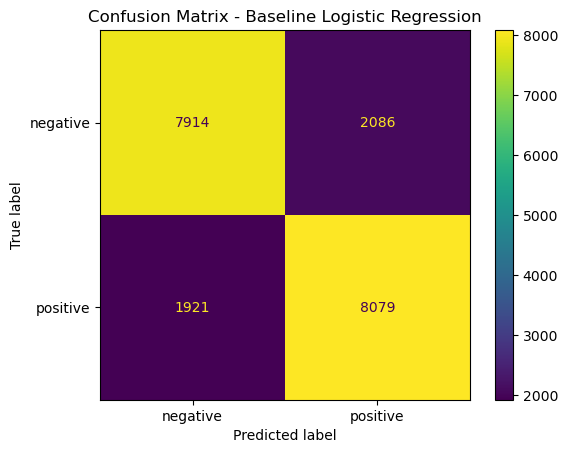

In [33]:
# Plot confusion matrix

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "positive"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.show()

## 9. Save Baseline Results

The baseline results are saved into a CSV file.  
These results will be used later for comparison with the deep learning model.

In [34]:
# Create results folder

results_dir = CURRENT_DIR / "results"
results_dir.mkdir(exist_ok=True)

# Create results table
baseline_results = pd.DataFrame({
    "model": ["Logistic Regression + TF-IDF"],
    "validation_accuracy": [val_accuracy],
    "validation_precision": [val_precision],
    "validation_recall": [val_recall],
    "validation_f1": [val_f1],
    "test_accuracy": [test_accuracy],
    "test_precision": [test_precision],
    "test_recall": [test_recall],
    "test_f1": [test_f1],
    "training_size": [len(X_train)],
    "validation_size": [len(X_val)],
    "test_size": [len(X_test)]
})

baseline_results_path = results_dir / "week02_baseline_results.csv"
baseline_results.to_csv(baseline_results_path, index=False)

baseline_results

,model,validation_accuracy,validation_precision,validation_recall,validation_f1,test_accuracy,test_precision,test_recall,test_f1,training_size,validation_size,test_size
0,Logistic Regression + TF-IDF,0.79885,0.794346,0.8065,0.800377,0.79965,0.794786,0.8079,0.801289,159998,20000,20000


In [35]:
print("Baseline results saved to:")
print(baseline_results_path)

Baseline results saved to:
C:\Users\SpaceX\results\week02_baseline_results.csv


## 10. Error Analysis

In this section, I inspect examples where the baseline model made mistakes.  
This helps to understand the limitations of the model.

In [36]:
# Create error analysis dataframe

error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_test_pred
})

error_df["true_sentiment"] = error_df["true_label"].map({
    0: "negative",
    1: "positive"
})

error_df["predicted_sentiment"] = error_df["predicted_label"].map({
    0: "negative",
    1: "positive"
})

wrong_predictions = error_df[error_df["true_label"] != error_df["predicted_label"]]

print("Number of wrong predictions:", len(wrong_predictions))
print("Total test examples:", len(error_df))

wrong_predictions.head(10)

Number of wrong predictions: 4007
Total test examples: 20000


,text,true_label,predicted_label,true_sentiment,predicted_sentiment
12,user oota love time differences was am when u ...,0,1,negative,positive
18,user heey girls i miss all you so back the cla...,1,0,positive,negative
21,user i'm sending u a lot of love no checks up ...,0,1,negative,positive
31,user i won't be able to recognize u when i see...,1,0,positive,negative
42,making me something to eat,1,0,positive,negative
45,bored please talk to me,1,0,positive,negative
47,summer school well my summer was fun while it ...,0,1,negative,positive
56,leavingggg disneyland,0,1,negative,positive
61,i starred on an user video check me and user o...,1,0,positive,negative
62,im goin back to my kampung this thursday mcm n...,1,0,positive,negative


In [37]:
# Show several wrong prediction examples

for i, row in wrong_predictions.sample(
    n=min(10, len(wrong_predictions)),
    random_state=42
).iterrows():
    print("Tweet:", row["text"])
    print("True label:", row["true_sentiment"])
    print("Predicted label:", row["predicted_sentiment"])
    print("-" * 80)

Tweet: woo hoo home from the dentist and no cavities
True label: positive
Predicted label: negative
--------------------------------------------------------------------------------
Tweet: the hangover is soldout going on an adventure with user
True label: negative
Predicted label: positive
--------------------------------------------------------------------------------
Tweet: reading today about content analysis and technological rhetoric and then out to the pool with the kid to to read some more
True label: negative
Predicted label: positive
--------------------------------------------------------------------------------
Tweet: the new look of finesse angels website give me feed back plz im still working on it
True label: positive
Predicted label: negative
--------------------------------------------------------------------------------
Tweet: won tickets to see team waterpolo
True label: positive
Predicted label: negative
---------------------------------------------------------------

## 14. Week 2 Conclusion

During Week 2, the tweet text was cleaned and prepared for machine learning.  
The dataset was split into training, validation, and test sets.  
A baseline model was trained using TF-IDF features and Logistic Regression.

The baseline model gives the first performance result for this project.  
In Week 3, I will implement a deep learning model using an LSTM neural network and compare it with this baseline.